# Training Data EDA

Explore the preprocessed training data used in the 3-model ensemble (V2).
- 8,345 training samples
- 39+ engineered features
- Log-transformed target (price_vnd)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
project_root = Path.cwd().parent
data_path = project_root / 'data' / 'processed' / 'model_training_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (10432, 86)

First few rows:
   num_floors  num_bedrooms  road_width_m  width_m  length_m  area_m2  \
0         3.0           3.0           4.0      4.1      12.5     50.0   
1         4.0           4.0           3.5      4.8       7.2     36.0   
2         2.0           3.0           5.0      4.0      11.0     44.0   
3         3.0           5.0          16.0      4.5      17.0    165.0   
4         3.0           4.0           5.0      4.0      14.0     55.0   

   locality_square  locality_population_density  distance_to_center_km  \
0              NaN                       38.042               3.067975   
1              NaN                       51.515               2.555122   
2              NaN                       22.190              11.026162   
3              NaN                       46.863               3.689532   
4              NaN                       22.190               9.748404   

   nearest_school_km  ...  terrace_bin_False  terrace_bin_True  \
0     

## Price Distribution

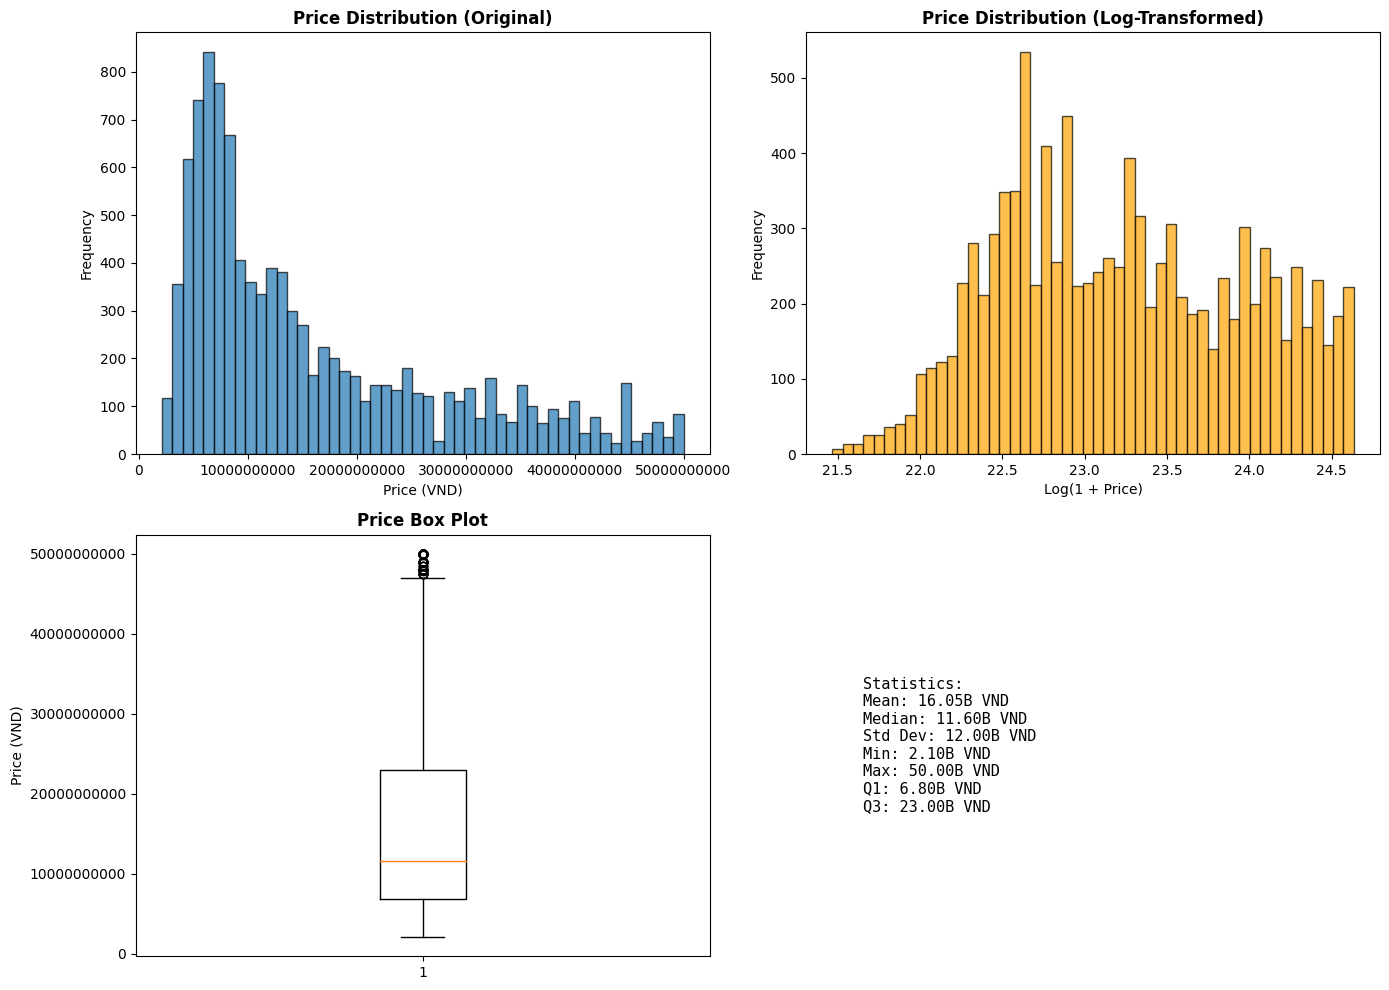

Price Statistics:
count    1.043200e+04
mean     1.604886e+10
std      1.199584e+10
min      2.100000e+09
25%      6.800000e+09
50%      1.160000e+10
75%      2.300000e+10
max      5.000000e+10
Name: price_vnd, dtype: float64


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original price
axes[0, 0].hist(df['price_vnd'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution (Original)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Log-transformed price
log_price = np.log1p(df['price_vnd'])
axes[0, 1].hist(log_price, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Price Distribution (Log-Transformed)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Log(1 + Price)')
axes[0, 1].set_ylabel('Frequency')

# Box plot
axes[1, 0].boxplot(df['price_vnd'])
axes[1, 0].set_title('Price Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Price (VND)')
axes[1, 0].ticklabel_format(style='plain', axis='y')

# Statistics
stats_text = f"""Statistics:
Mean: {df['price_vnd'].mean()/1e9:.2f}B VND
Median: {df['price_vnd'].median()/1e9:.2f}B VND
Std Dev: {df['price_vnd'].std()/1e9:.2f}B VND
Min: {df['price_vnd'].min()/1e9:.2f}B VND
Max: {df['price_vnd'].max()/1e9:.2f}B VND
Q1: {df['price_vnd'].quantile(0.25)/1e9:.2f}B VND
Q3: {df['price_vnd'].quantile(0.75)/1e9:.2f}B VND"""

axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', family='monospace')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(project_root / 'models' / 'saved_models' / 'plots' / '00_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Price Statistics:")
print(df['price_vnd'].describe())

## Price Segmentation

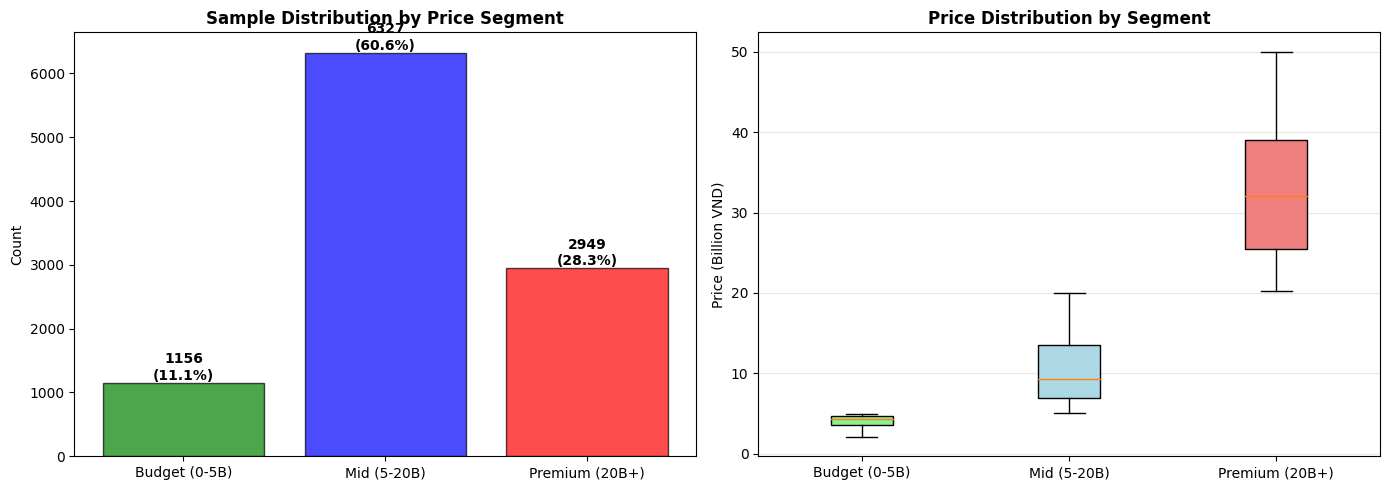


Segment Distribution:
price_segment
Budget (0-5B)     1156
Mid (5-20B)       6327
Premium (20B+)    2949
Name: count, dtype: int64

Percentages:
price_segment
Budget (0-5B)     11.081288
Mid (5-20B)       60.649923
Premium (20B+)    28.268788
Name: count, dtype: float64


In [3]:
# Segment prices
bins = [0, 5e9, 20e9, float('inf')]
labels = ['Budget (0-5B)', 'Mid (5-20B)', 'Premium (20B+)']
df['price_segment'] = pd.cut(df['price_vnd'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment counts
segment_counts = df['price_segment'].value_counts().sort_index()
axes[0].bar(range(len(segment_counts)), segment_counts.values, edgecolor='black', alpha=0.7, color=['green', 'blue', 'red'])
axes[0].set_xticks(range(len(segment_counts)))
axes[0].set_xticklabels(segment_counts.index)
axes[0].set_title('Sample Distribution by Price Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Add percentages
for i, (count, pct) in enumerate(zip(segment_counts.values, 100*segment_counts.values/len(df))):
    axes[0].text(i, count, f"{count}\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold')

# Segment box plots
segment_data = [df[df['price_segment']==seg]['price_vnd']/1e9 for seg in labels]
bp = axes[1].boxplot(segment_data, labels=labels, patch_artist=True)
colors = ['lightgreen', 'lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_title('Price Distribution by Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (Billion VND)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'models' / 'saved_models' / 'plots' / '01_price_segments.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSegment Distribution:")
print(segment_counts)
print(f"\nPercentages:")
print(segment_counts / len(df) * 100)

## Feature Overview

In [4]:
# Exclude price_vnd and price_segment from feature analysis
features = [col for col in df.columns if col not in ['price_vnd', 'price_segment']]

print(f"Total features: {len(features)}")
print(f"\nFeature types:")
print(df[features].dtypes.value_counts())

print(f"\nNumeric features summary:")
numeric_features = df[features].select_dtypes(include=[np.number]).columns
print(f"Count: {len(numeric_features)}")
print(df[numeric_features].describe().T[['count', 'mean', 'std', 'min', 'max']].head(15))

Total features: 85

Feature types:
bool       35
float64    28
int64      22
Name: count, dtype: int64

Numeric features summary:
Count: 50
                               count        mean        std        min  \
num_floors                   10252.0    3.292333   1.598485   1.000000   
num_bedrooms                 10314.0    5.415261   5.792364   1.000000   
road_width_m                 10410.0   11.265802  10.804748   1.000000   
width_m                      10432.0    5.463977   5.398400   1.000000   
length_m                     10432.0   17.698187   7.456819   1.000000   
area_m2                      10432.0   95.715203  62.205147  15.000000   
locality_square                  0.0         NaN        NaN        NaN   
locality_population_density  10427.0   31.757164  16.833684   1.166000   
distance_to_center_km        10432.0    6.911704   4.426010   0.172068   
nearest_school_km            10432.0    0.313066   0.290759   0.000000   
school_count_3km             10432.0  100.6131

## Correlation Analysis

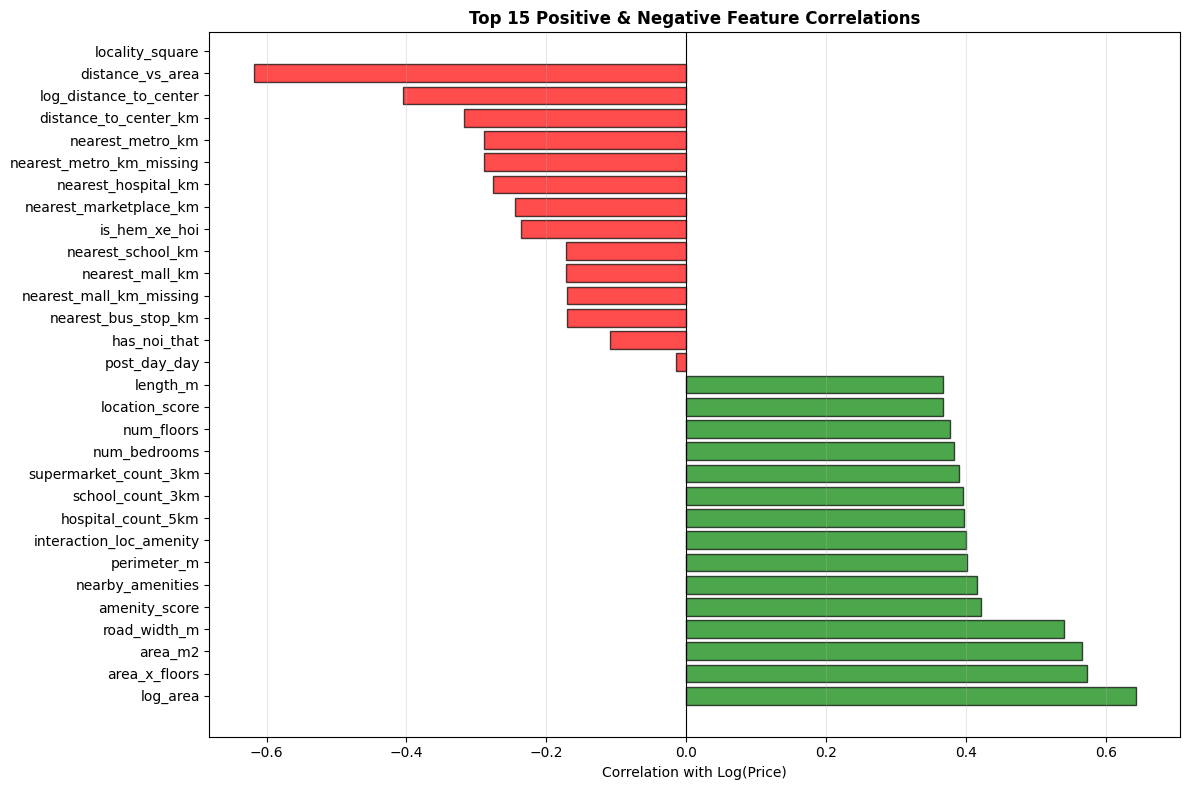


Top 20 positive correlations:
log_area                       0.642712
area_x_floors                  0.572690
area_m2                        0.565848
road_width_m                   0.539662
amenity_score                  0.421374
nearby_amenities               0.415044
perimeter_m                    0.400757
interaction_loc_amenity        0.399744
hospital_count_5km             0.396592
school_count_3km               0.395947
supermarket_count_3km          0.390059
num_bedrooms                   0.382066
num_floors                     0.376791
location_score                 0.367265
length_m                       0.367095
bus_stop_count_1km             0.357782
mall_count_3km                 0.347638
area_x_bedrooms                0.343333
locality_population_density    0.340345
log_population_density         0.337730
Name: log_price, dtype: float64

Top 10 negative correlations:
nearest_school_km          -0.172200
is_hem_xe_hoi              -0.235838
nearest_marketplace_km     -0.24

In [5]:
# Correlation with price
numeric_data = df[numeric_features].copy()
numeric_data['price_vnd'] = df['price_vnd']
numeric_data['log_price'] = np.log1p(df['price_vnd'])

corr_with_price = numeric_data.corr()['log_price'].drop(['price_vnd', 'log_price']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_features = pd.concat([corr_with_price.head(15), corr_with_price.tail(15)])
colors = ['green' if x > 0 else 'red' for x in top_features.values]
ax.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Correlation with Log(Price)')
ax.set_title('Top 15 Positive & Negative Feature Correlations', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'models' / 'saved_models' / 'plots' / '02_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTop 20 positive correlations:")
print(corr_with_price.head(20))
print(f"\nTop 10 negative correlations:")
print(corr_with_price.tail(10))

## Property Type Analysis

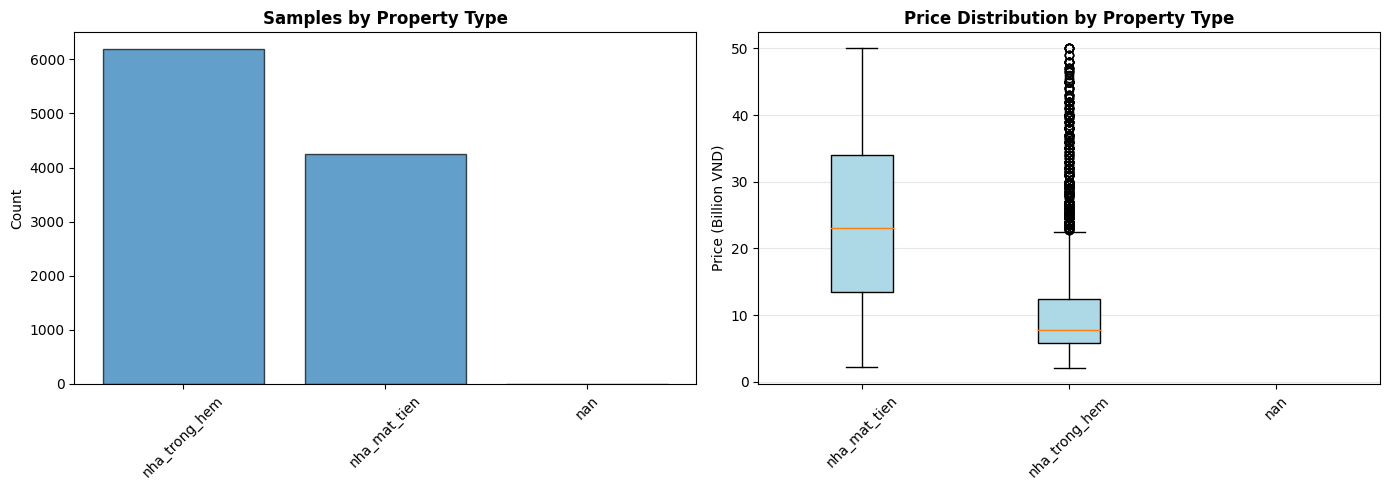


Property Type Distribution:
property_type_nha_trong_hem    6189
property_type_nha_mat_tien     4243
property_type_nan                 0
dtype: int64


In [6]:
# Property type columns
ptype_cols = [col for col in df.columns if 'property_type' in col]

if ptype_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count by property type
    ptype_counts = df[ptype_cols].sum().sort_values(ascending=False)
    axes[0].bar(range(len(ptype_counts)), ptype_counts.values, edgecolor='black', alpha=0.7)
    axes[0].set_xticks(range(len(ptype_counts)))
    axes[0].set_xticklabels([col.replace('property_type_', '') for col in ptype_counts.index], rotation=45)
    axes[0].set_title('Samples by Property Type', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    
    # Price by property type
    ptype_data = []
    ptype_labels = []
    for col in ptype_cols:
        ptype_data.append(df[df[col]==1]['price_vnd']/1e9)
        ptype_labels.append(col.replace('property_type_', ''))
    
    bp = axes[1].boxplot(ptype_data, labels=ptype_labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[1].set_title('Price Distribution by Property Type', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Price (Billion VND)')
    axes[1].grid(axis='y', alpha=0.3)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.savefig(project_root / 'models' / 'saved_models' / 'plots' / '03_property_type_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nProperty Type Distribution:")
    print(ptype_counts)
else:
    print("No property type columns found")

## Summary

In [7]:
print(f"""
╔═══════════════════════════════════════════════════════════════╗
║          TRAINING DATA SUMMARY (3-Model Ensemble V2)          ║
╠═══════════════════════════════════════════════════════════════╣
║ Total Samples:     {len(df):,}                                 ║
║ Features:          {len(features)}                                   ║
║ Numeric Features:  {len(numeric_features)}                                   ║
║                                                               ║
║ Price Range:       {df['price_vnd'].min()/1e9:.2f}B - {df['price_vnd'].max()/1e9:.2f}B VND      ║
║ Mean Price:        {df['price_vnd'].mean()/1e9:.2f}B VND                  ║
║ Median Price:      {df['price_vnd'].median()/1e9:.2f}B VND                  ║
║                                                               ║
║ Budget (0-5B):     {len(df[df['price_vnd'] < 5e9]):,} ({100*len(df[df['price_vnd'] < 5e9])/len(df):.1f}%)          ║
║ Mid (5-20B):       {len(df[(df['price_vnd'] >= 5e9) & (df['price_vnd'] < 20e9)]):,} ({100*len(df[(df['price_vnd'] >= 5e9) & (df['price_vnd'] < 20e9)])/len(df):.1f}%)          ║
║ Premium (20B+):    {len(df[df['price_vnd'] >= 20e9]):,} ({100*len(df[df['price_vnd'] >= 20e9])/len(df):.1f}%)            ║
╚═══════════════════════════════════════════════════════════════╝
""")

print(f"\nPlots saved to: models/saved_models/plots/")
print(f"- 00_price_distribution.png")
print(f"- 01_price_segments.png")
print(f"- 02_feature_correlations.png")
print(f"- 03_property_type_analysis.png")


╔═══════════════════════════════════════════════════════════════╗
║          TRAINING DATA SUMMARY (3-Model Ensemble V2)          ║
╠═══════════════════════════════════════════════════════════════╣
║ Total Samples:     10,432                                 ║
║ Features:          85                                   ║
║ Numeric Features:  50                                   ║
║                                                               ║
║ Price Range:       2.10B - 50.00B VND      ║
║ Mean Price:        16.05B VND                  ║
║ Median Price:      11.60B VND                  ║
║                                                               ║
║ Budget (0-5B):     1,120 (10.7%)          ║
║ Mid (5-20B):       6,296 (60.4%)          ║
║ Premium (20B+):    3,016 (28.9%)            ║
╚═══════════════════════════════════════════════════════════════╝


Plots saved to: models/saved_models/plots/
- 00_price_distribution.png
- 01_price_segments.png
- 02_feature_correlations.png
- 03_